# Forecasting mAb production: completed project

**Simulation → batch-separated data → model comparison → saved forecasting.**

This notebook presents the completed extension of [project_proposal.pdf](../docs/project_proposal.pdf). It loads
already trained models and results; running it does not retrain the experiment.
To regenerate the entire study, run `python run_project.py` from the project root.
See [final_report.pdf](../docs/final_report.pdf) for the final report.

The selected predictor is ridge regression with a cubic correction to a local
trend. Improved LSTM and MLP models are included and compared on the same task.
All validation here is on synthetic data with fixed kinetics and constant
controls. The measurement-noise test reveals substantial sensitivity.

In [1]:
%matplotlib inline
from pathlib import Path
import os
import sys

PROJECT_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
                     if (p / "bioreactor.py").is_file() and (p / "forecasting").is_dir()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("Open this notebook from within the project directory.")
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
Path("results/simulation").mkdir(parents=True, exist_ok=True)
Path("data").mkdir(parents=True, exist_ok=True)

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Image, Markdown, display

from bioreactor import Operation
from forecasting.models import predict_artifact
from forecasting.serialization import load_mab_results
from forecasting.prediction import forecast_csv, read_history

results = Path("results/final")
metrics = load_mab_results(results / "metrics.json")
selection = load_mab_results(results / "selection.json")
manifest = json.loads((results / "data/manifest.json").read_text())
print("Selected model:", metrics["selected_model"])
print("Whole-batch split:", manifest["counts"])
print("Selection used test data:", selection["test_used_for_selection"])

Selected model: ridge
Whole-batch split: {'train': 48, 'validation': 12, 'calibration': 12, 'test': 16}
Selection used test data: False


## Evaluation design

The dataset contains 48 training, 12 validation, 12 calibration, and 16 test
batches. Each batch belongs to one split. Six state histories and five known
operating settings form the input. Twenty observations at 20-minute intervals
span 380 minutes. The output is 50 future mAb values over the next 1,000 minutes.

Training targets end at 5,000 minutes. The later-time test forecasts 5,000–6,000
minutes on unseen test batches. The model receives no future reactor states.
Selection uses validation RMSE; calibration batches set the interval width.
The same horizons and batch splits are used for every model below.

| Model | Validation RMSE | Unseen-batch RMSE | Later-time RMSE |
| --- | ---: | ---: | ---: |
| ridge | 0.00432817 | 0.00521468 | 0.0485464 |
| mlp_seed29 | 0.0383076 | 0.0469074 | 0.121366 |
| mlp_ensemble | 0.0405997 | 0.0481772 | 0.101811 |
| mlp_seed11 | 0.0440329 | 0.0412891 | 0.12027 |
| mlp_seed47 | 0.0479112 | 0.0628294 | 0.143346 |
| lstm_seed29 | 0.077452 | 0.0967242 | 0.560357 |
| lstm_seed11 | 0.0874324 | 0.088393 | 0.611359 |
| lstm_ensemble | 0.0901132 | 0.0915238 | 0.638449 |
| lstm_seed47 | 0.129582 | 0.113819 | 0.755019 |
| quadratic | 0.24144 | 0.230674 | 0.162119 |
| linear_drift | 2.81533 | 2.92435 | 4.09326 |
| persistence | 18.1188 | 19.6768 | 43.0714 |

All errors above are in mg/L.


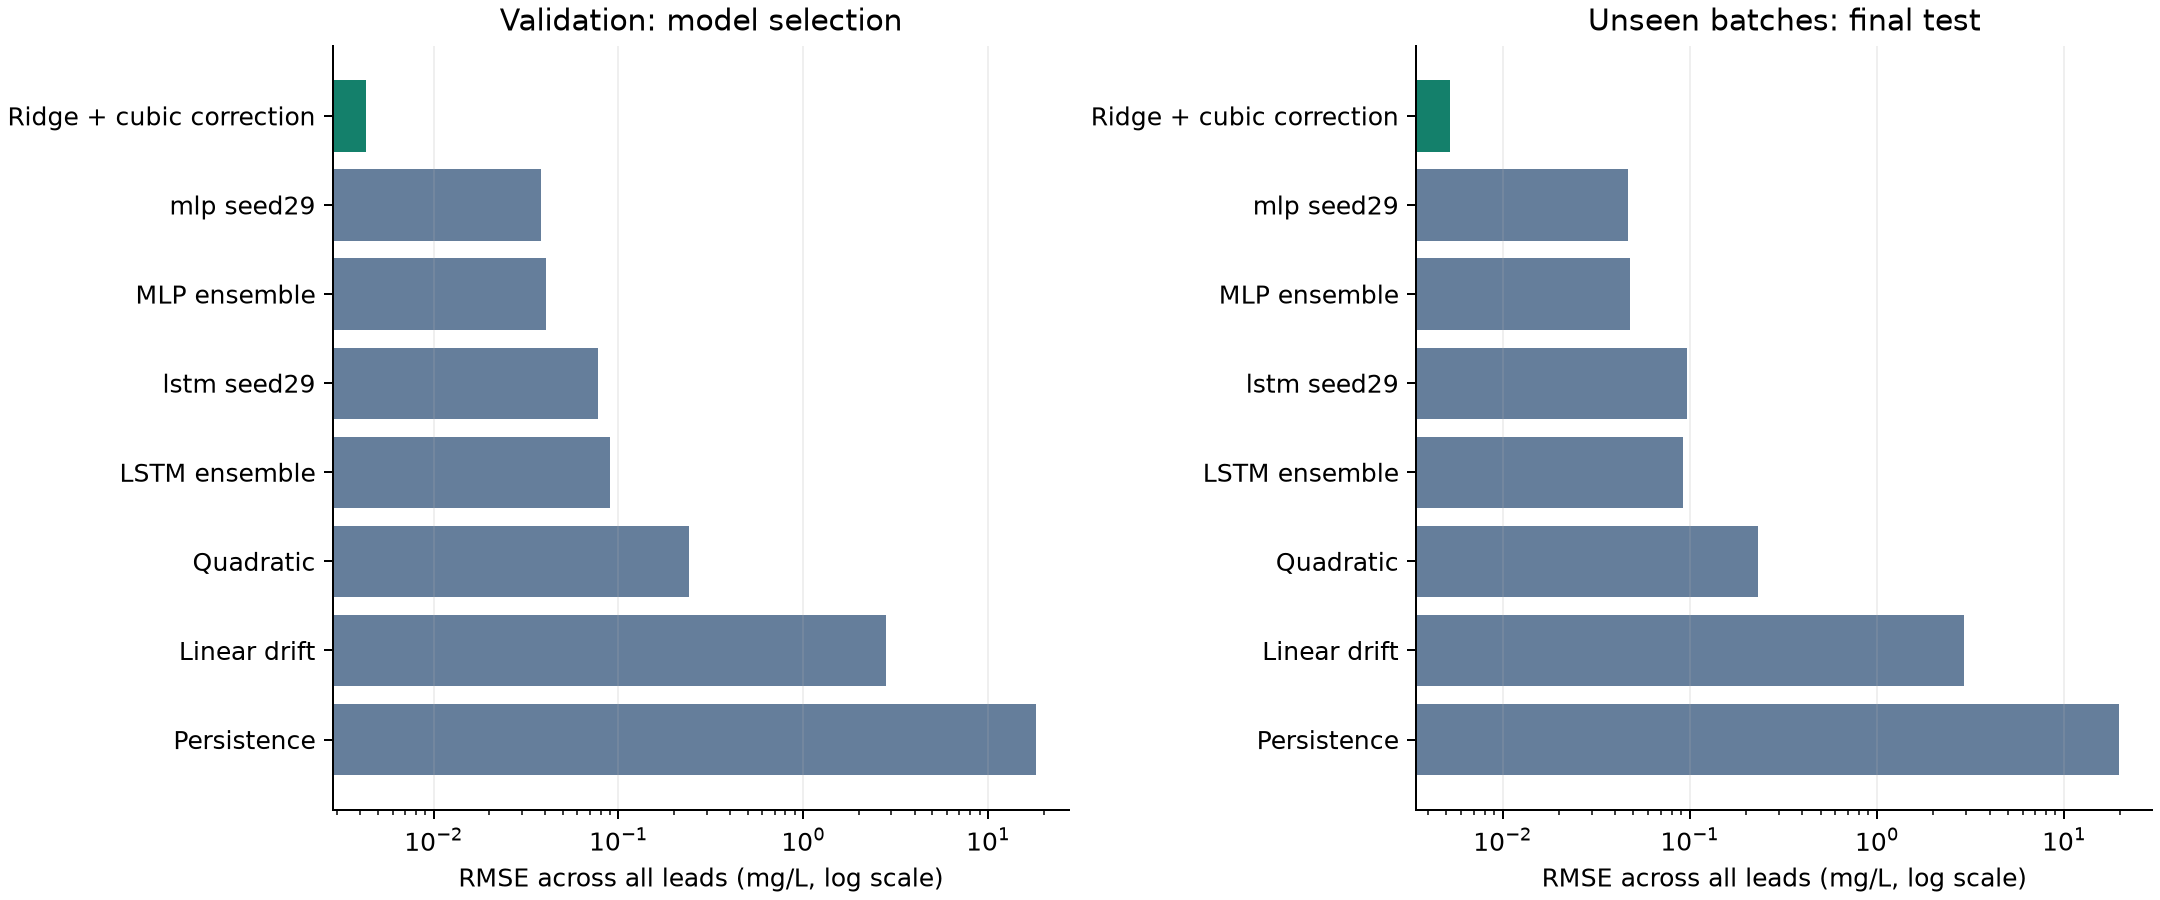

In [2]:
rows = ["| Model | Validation RMSE | Unseen-batch RMSE | Later-time RMSE |",
        "| --- | ---: | ---: | ---: |"]
for name in sorted(metrics["validation"], key=lambda n: metrics["validation"][n]["rmse_mg_L"]):
    values = [metrics[split][name]["rmse_mg_L"]
              for split in ("validation", "test", "future_time_test")]
    rows.append(f"| {name} | {values[0]:.6g} | {values[1]:.6g} | {values[2]:.6g} |")
display(Markdown("\n".join(rows)))
print("All errors above are in mg/L.")
display(Image(filename=str(results / "model_comparison.png"), width=1000))

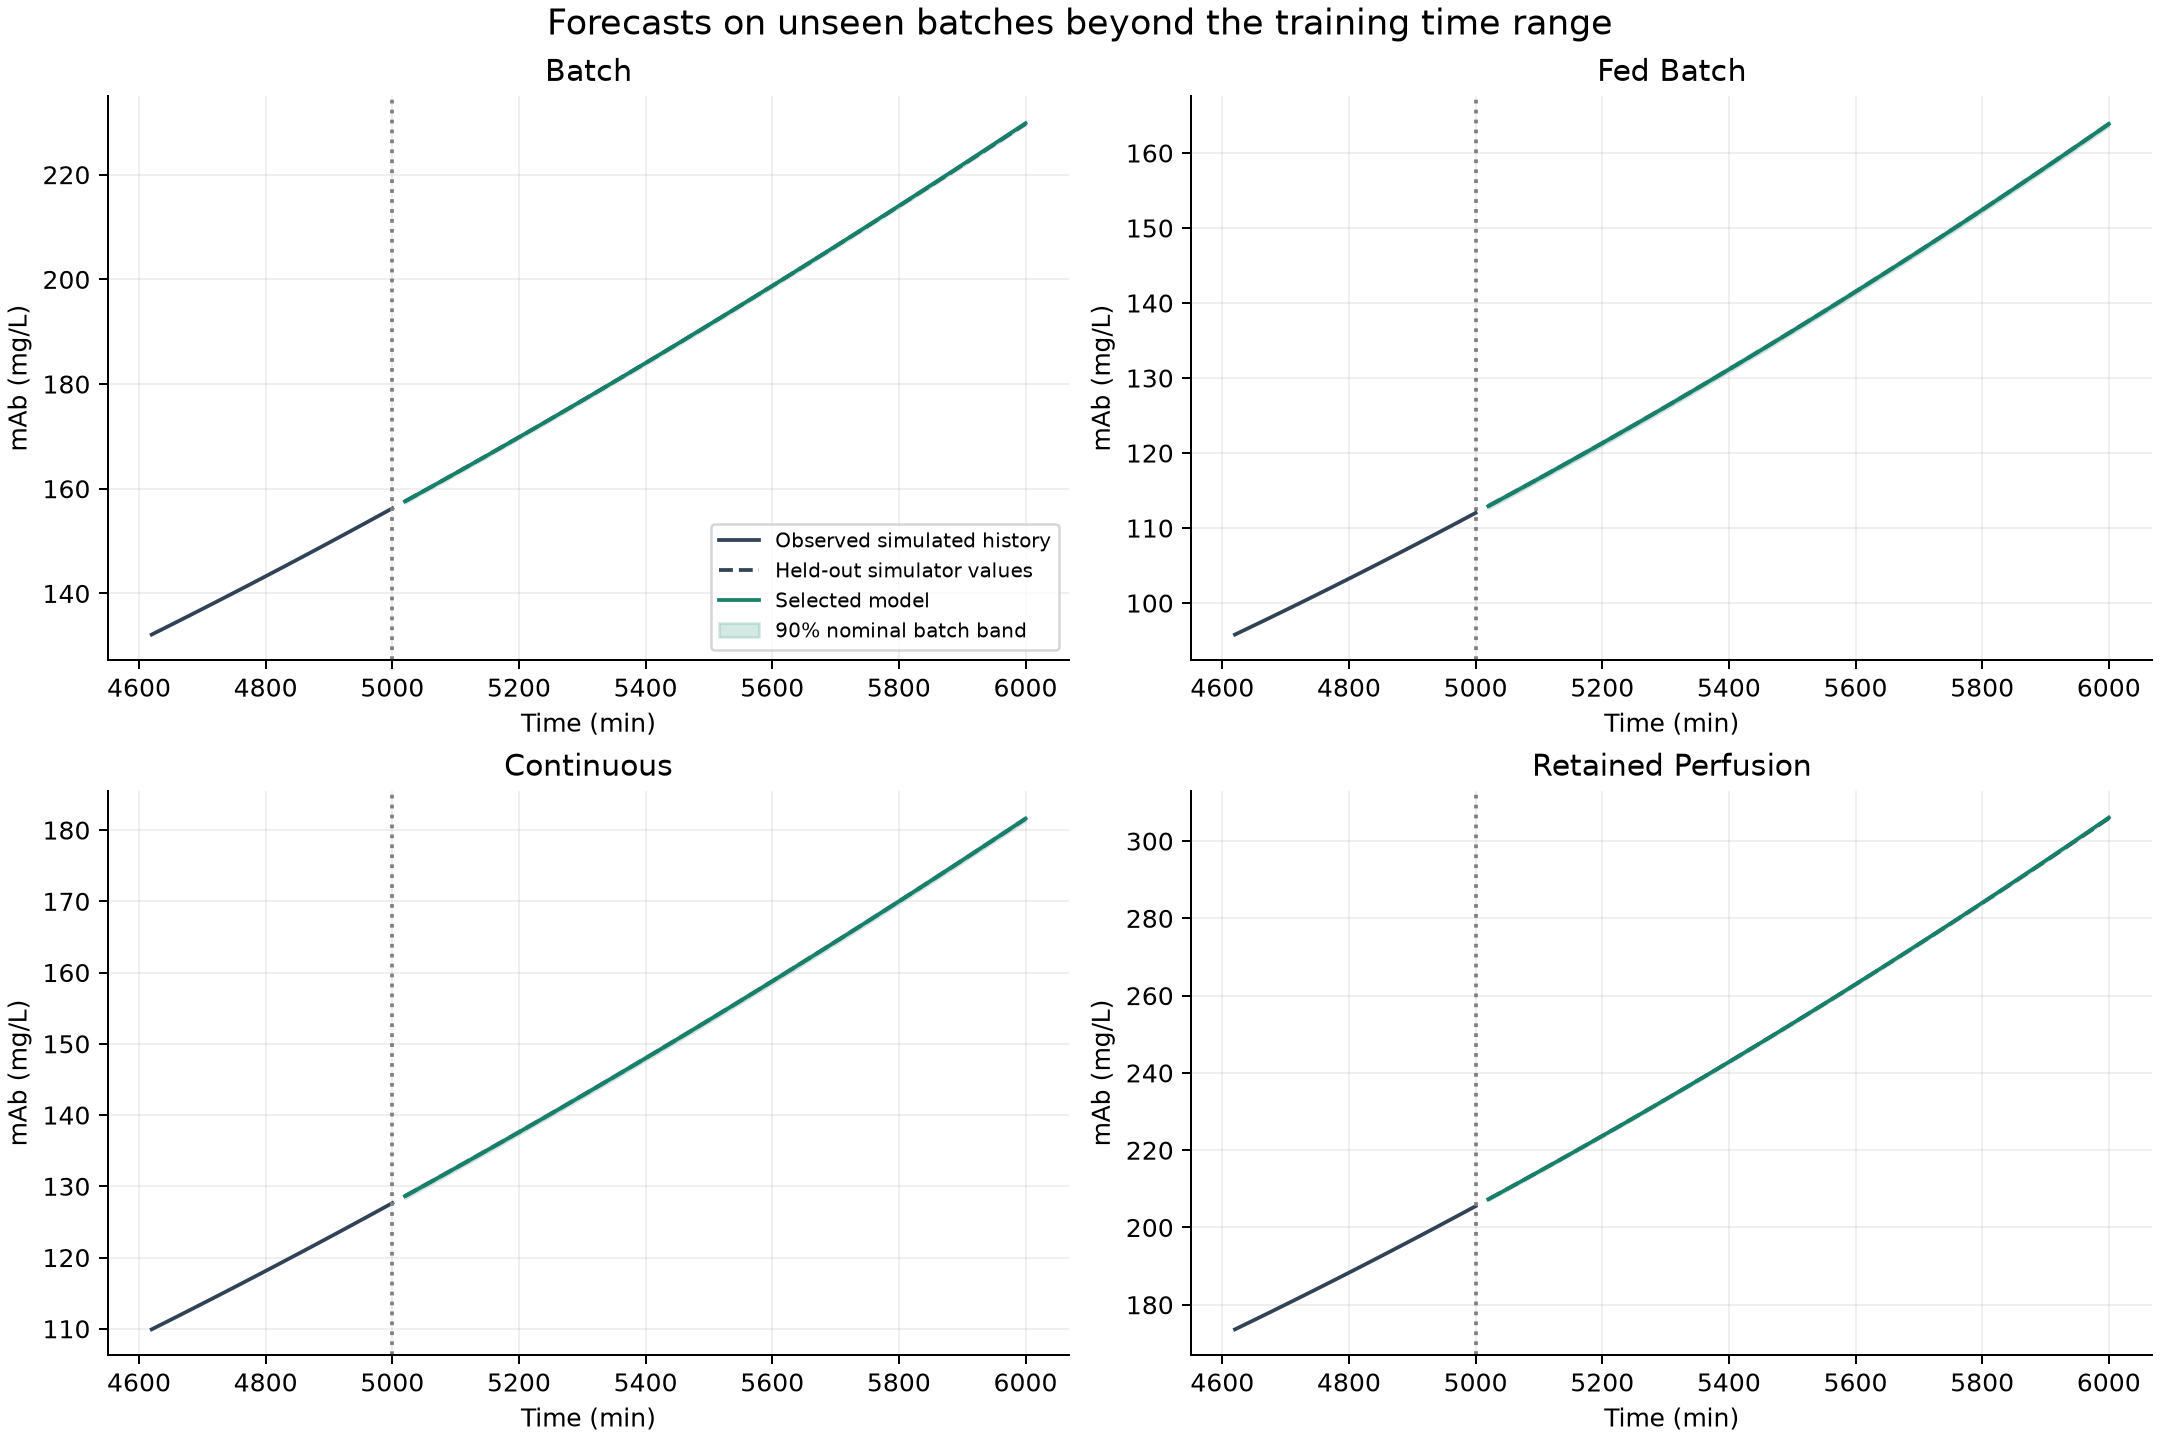

Selected model's test errors by forecast lead:
  60 min: RMSE 0.000452097 mg/L
  240 min: RMSE 0.000517173 mg/L
  1000 min: RMSE 0.0123759 mg/L


In [3]:
display(Image(filename=str(results / "heldout_forecasts.png"), width=1000))
selected = metrics["selected_model"]
print("Selected model's test errors by forecast lead:")
for lead, scores in metrics["test"][selected]["by_lead"].items():
    print(f"  {lead} min: RMSE {scores['rmse_mg_L']:.6g} mg/L")

## Generate a forecast from the project history

The saved predictor uses the final 20 compatible observations from
`data/example_batch.csv`. The original one-minute samples are selected at
20-minute spacing; values are not interpolated. Operating settings must match
the recorded run and remain constant through the forecast.

The default history is a 308 K batch. Its final mAb/glucose history lies beyond
some empirical training ranges, so the metadata flags those inputs. The later
time evaluation above explicitly tests this type of extrapolation.

In [4]:
operation = Operation()  # Matches the supplied 308 K batch history.
forecast, forecast_metadata = forecast_csv(
    history_path="data/example_batch.csv",
    model_path=results / "best_model.pt",
    output_path=results / "project_forecast.csv",
    operation=operation,
    minutes=1000,
)
print("Forecast interval:", forecast[0, 0], "to", forecast[-1, 0], "minutes")
print("Final prediction:", forecast[-1, 1], "mg/L")
print("Outside training support:", forecast_metadata["outside_training_support"])

Forecast saved to results/final/project_forecast.csv; model=ridge; final mab_mg_L=230.9091
Outside training support: mab_mg_L, glucose_g_L
Forecast interval: 5020.0 to 6000.0 minutes
Final prediction: 230.9090729405346 mg/L
Outside training support: ['mab_mg_L', 'glucose_g_L']


## Use the trained LSTM too

The LSTM below is selected among the LSTM candidates using validation scores.
It predicts the entire horizon directly, using observed multivariate history
and a trend correction. This is the improved model; the original univariate
report architecture remains in `baselines/univariate_lstm.py`.

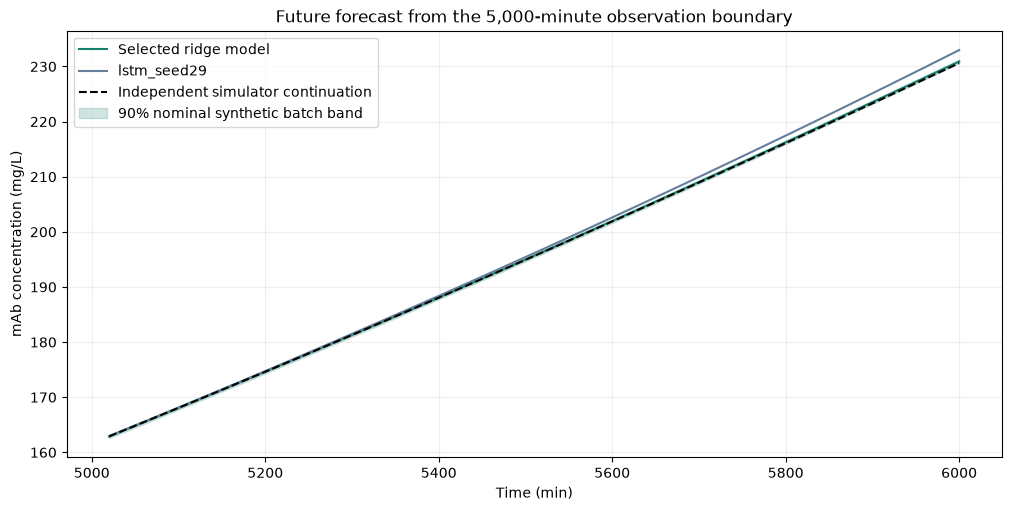

In [5]:
lstm_name = min(
    (name for name in metrics["validation"] if name.startswith("lstm")),
    key=lambda name: metrics["validation"][name]["rmse_mg_L"],
)
lstm_artifact = torch.load(results / "checkpoints" / f"{lstm_name}.pt",
                           map_location="cpu", weights_only=True)
history, origin, support_flags = read_history("data/example_batch.csv", lstm_artifact, operation)
lstm_forecast = predict_artifact(lstm_artifact, history)[0]

reference = np.loadtxt(results / "project_reference.csv", delimiter=",", skiprows=1)
fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
ax.plot(forecast[:, 0], forecast[:, 1], label="Selected ridge model", color="#16806B")
ax.plot(forecast[:, 0], lstm_forecast, label=lstm_name, color="#657E9B")
ax.plot(reference[:, 0], reference[:, 1], "--", color="black", label="Independent simulator continuation")
ax.fill_between(forecast[:, 0], forecast[:, 2], forecast[:, 3], alpha=.2,
                color="#16806B", label="90% nominal synthetic batch band")
ax.set(xlabel="Time (min)", ylabel="mAb concentration (mg/L)",
       title="Future forecast from the 5,000-minute observation boundary")
ax.grid(alpha=.2)
ax.legend()
plt.show()

## Uncertainty and measurement noise

The 90% band is calibrated with one maximum-error score per independent
calibration batch, across its windows and horizons. It targets simultaneous
coverage for another batch from the same synthetic process. It does not
establish coverage on experimental or noisy data.

The noise test perturbs observed state channels with Gaussian noise whose SD
is 0.5% of each feature's training SD. This is a sensitivity scenario, not a
measured sensor model. Test noise does not select or retrain the model.

The usual conformal guarantee assumes exchangeable calibration and future batches.
Operating modes are balanced by design here, so pooled exchangeability is not
established; the reported coverage is empirical, not a guarantee for each mode.

Calibration and coverage: {'nominal_batch_coverage': 0.9, 'radius_mg_L': 0.31678827975713375, 'test_batch_coverage': 1.0, 'test_point_coverage': 1.0, 'calibration_batches': 12}
Selected clean RMSE: 0.005214682374581241 mg/L
Selected perturbed-input RMSE: 6.799642772149988 mg/L


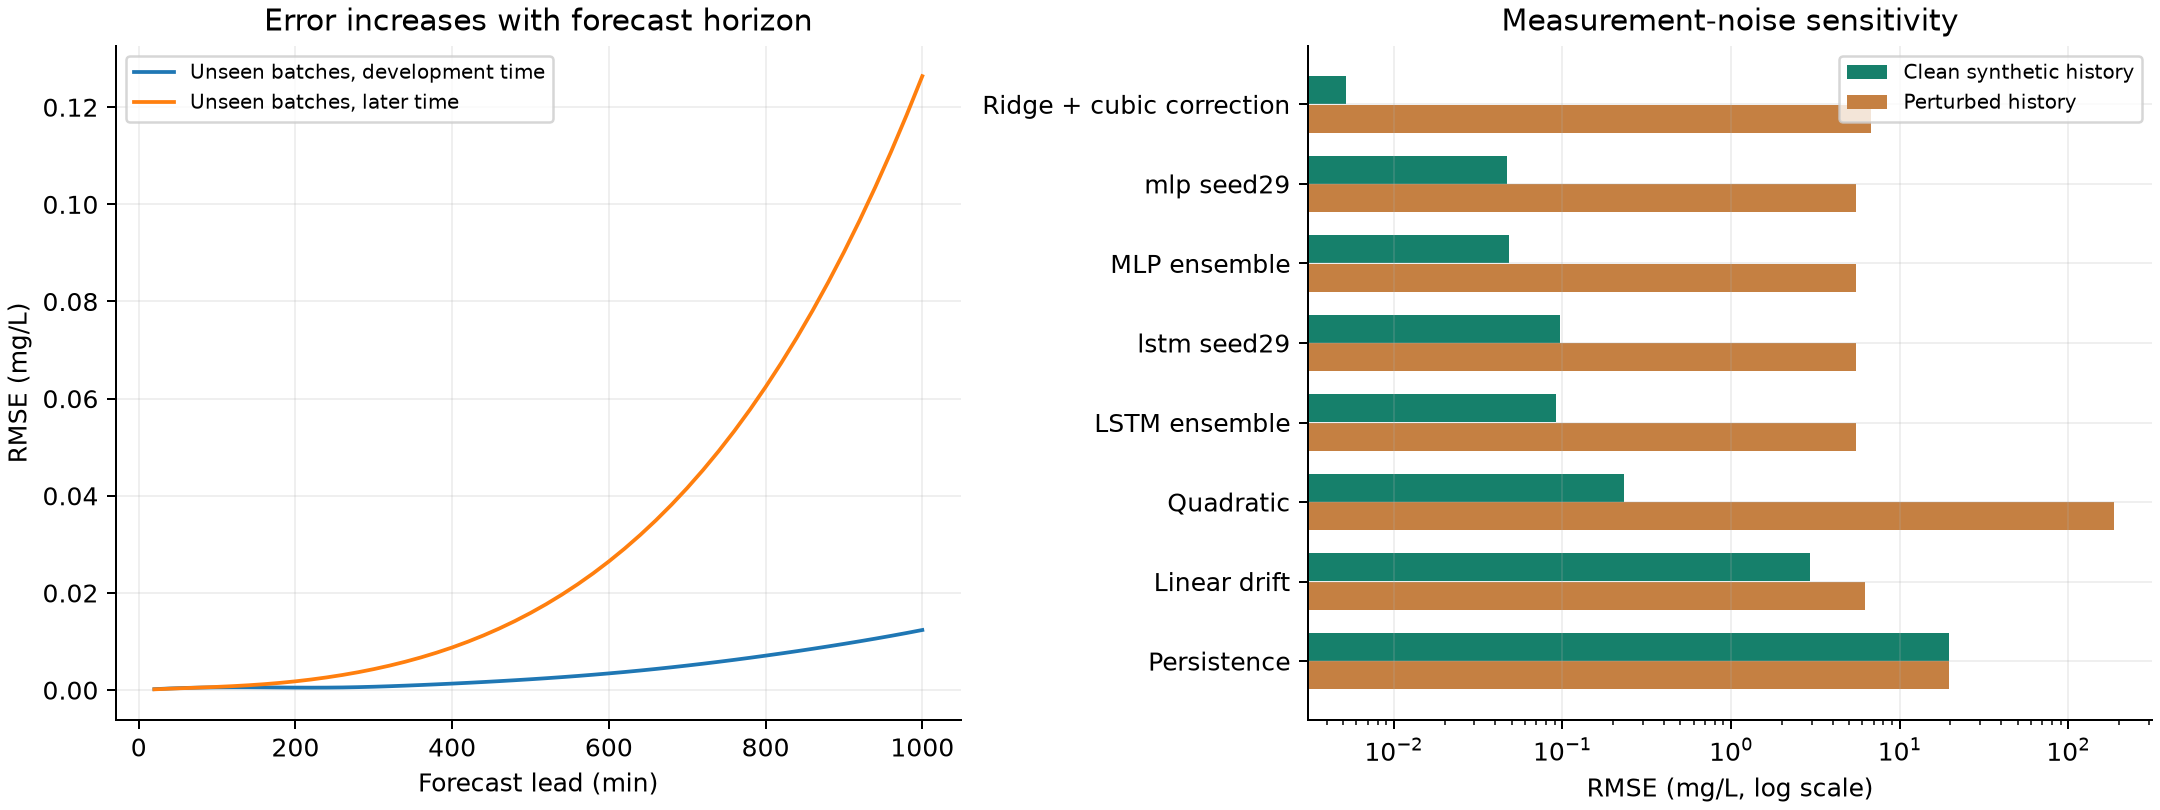

In [6]:
print("Calibration and coverage:", metrics["intervals"])
print("Selected clean RMSE:", metrics["test"][selected]["rmse_mg_L"], "mg/L")
print("Selected perturbed-input RMSE:",
      metrics["measurement_noise_sensitivity"]["scores"][selected]["rmse_mg_L"], "mg/L")
display(Image(filename=str(results / "error_and_noise.png"), width=1000))

## Reproduce and use

```sh
python -m pip install -r requirements.txt
python run_project.py
python -m unittest discover -s tests -v
```

Use `python predict_mab.py` for inference without retraining. Use
`python run_project.py --report-only` to rebuild the final figures/report.

The computational project is complete. Experimental validation, noisy-input
modeling, and recalibration on measured batches remain necessary before using
these forecasts for laboratory or plant decisions. The original project brief is preserved in `docs/project_proposal.pdf`.